# Generate test images and fake aquisition from the mnt data

In [67]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random

In [79]:
#Load the data
file_path = '../Datas/FinalData/TI/TI_Alt1_Alti3D.tif'
size_img = np.array([200,200])
number_of_aquisition_lines = 3
definer_border = True
error = 2

if os.path.isfile(file_path):
    print('Le fichier est présent. import')
    data_DEM = gr.from_file(file_path)
    (xmin, xsize, x, ymax, y, ysize) = data_DEM.geot

else:
    print('error')

Le fichier est présent. import


masked_array(
  data=[[-3.4028230607370965e+38, -3.4028230607370965e+38,
         -3.4028230607370965e+38, ..., -3.4028230607370965e+38,
         -3.4028230607370965e+38, -3.4028230607370965e+38],
        [-3.4028230607370965e+38, -3.4028230607370965e+38,
         -3.4028230607370965e+38, ..., -3.4028230607370965e+38,
         -3.4028230607370965e+38, -3.4028230607370965e+38],
        [-3.4028230607370965e+38, -3.4028230607370965e+38,
         -3.4028230607370965e+38, ..., -3.4028230607370965e+38,
         -3.4028230607370965e+38, -3.4028230607370965e+38],
        ...,
        [-3.4028230607370965e+38, -3.4028230607370965e+38,
         -3.4028230607370965e+38, ..., -3.4028230607370965e+38,
         -3.4028230607370965e+38, -3.4028230607370965e+38],
        [-3.4028230607370965e+38, -3.4028230607370965e+38,
         -3.4028230607370965e+38, ..., -3.4028230607370965e+38,
         -3.4028230607370965e+38, -3.4028230607370965e+38],
        [-3.4028230607370965e+38, -3.4028230607370965e+38,

In [3]:
print('Sizes Infos :')

print(data_DEM.geot)
print(data_DEM.shape)



Sizes Infos :
(583236.0, 2.0, 0.0, 130498.0, 0.0, -2.0)
(984, 1155)


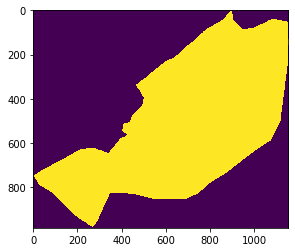

In [28]:
mask_where_nodata = data_DEM.raster != np.min(data_DEM.raster)

plt.imshow(mask_where_nodata)

In [5]:
data_DEM.shape[0]

984

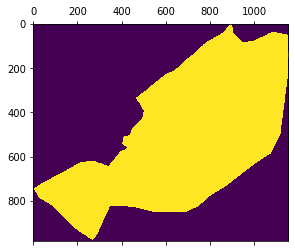

In [6]:
data_DEM.plot()

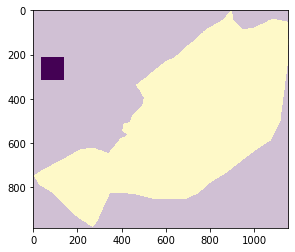

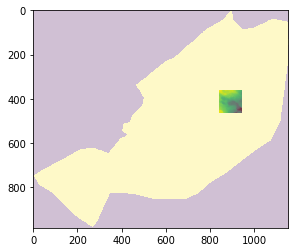

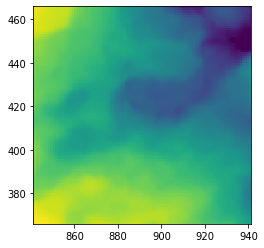

In [78]:
res = False
while res == False:
    plt.close()
    size_img_c = (np.round(size_img / data_DEM.geot[1]))
    rdm_X = int(round(random()*(data_DEM.shape[1] - size_img_c[0])))
    rdm_Y = int(round(random()*(data_DEM.shape[0] - size_img_c[1])))

    box = [rdm_X, int(rdm_X+size_img_c[0]),rdm_Y,int(rdm_Y+size_img_c[1])]
    mask_cut = mask_where_nodata[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    raster_cut = data_DEM.raster[rdm_Y:(rdm_Y+int(size_img_c[1])),rdm_X:int((rdm_X+size_img_c[0]))]
    res = np.all(mask_cut)
    #a = np.ones(raster_cut.shape)*100000000
    plt.imshow(raster_cut, extent = box)
    plt.imshow(data_DEM.raster,alpha=0.25)
    
    plt.show()
    time.sleep(3)
    
plt.figure()
plt.imshow(raster_cut, extent = box)



In [215]:
hard_data = []
line = np.zeros([2,2])

#for i in range(number_of_aquisition_lines)

top = [round(random()),round(random())]
if top[0] == 1:  #Vertical start
    line[:,0] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[2]])#return a x value, defined a y
else:
    line[:,0] = np.array([box[0],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y

if top[1] == 1:
    line[:,1] = np.array([round(random()*(box[1]-box[0]) + box[0]),box[3]]) #return a x value, defined a y
else:
    line[:,1] = np.array([box[1],round(random()*(box[3]-box[2]) + box[2])]) #return a x value, defined a y
    
dx = np.max(np.diff(line))

x_pos = np.round(np.linspace(line[0,0],line[0,1],num =dx))
y_pos = np.round(np.linspace(line[1,0],line[1,1],num =dx))



d = {'cell_x': x_pos, 'cell_y': y_pos}
pos_index = pd.DataFrame(d)
pos_index["cell_x"] = pos_index["cell_x"].astype(int)
pos_index["cell_y"] = pos_index["cell_y"].astype(int)
pos_index['alt'] = data_DEM.raster[pos_index["cell_y"],pos_index["cell_x"]]

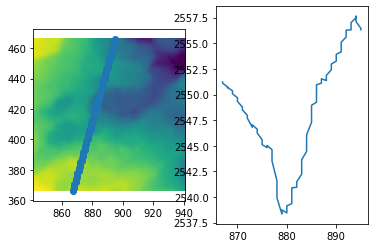

In [217]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(raster_cut, extent = box)
ax1.scatter(pos_index["cell_x"],pos_index["cell_y"] )

ax2.plot(pos_index["cell_x"],pos_index["alt"])

In [143]:
line

array([[841., 904.],
       [398., 466.]])

In [144]:
841 - 904 

-63